# Text Clustering and Topic Modelling

<img src="./images/genai_68.png" width=1000 />

Applications :

Finding outliers

Finding incorrectly labelled data

Discover abstract topics that appear in large collections of textual data

<img src="./images/genai_69.png" width=1000 />

In [1]:
from datasets import load_dataset

In [2]:
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

In [3]:
len(dataset)

44949

In [4]:
dataset[0]

{'Titles': 'Introduction to Arabic Speech Recognition Using CMUSphinx System',
 'Abstracts': '  In this paper Arabic was investigated from the speech recognition problem\npoint of view. We propose a novel approach to build an Arabic Automated Speech\nRecognition System (ASR). This system is based on the open source CMU Sphinx-4,\nfrom the Carnegie Mellon University. CMU Sphinx is a large-vocabulary;\nspeaker-independent, continuous speech recognition system based on discrete\nHidden Markov Models (HMMs). We build a model using utilities from the\nOpenSource CMU Sphinx. We will demonstrate the possible adaptability of this\nsystem to Arabic voice recognition.\n',
 'Years': 2007,
 'Categories': 'Computation and Language'}

In [5]:
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

### Steps involved in text clustering

1.  Convert the input documents to embeddings with an embedding model.

2.  Reduce the dimensionality of embeddings with a dimensionality reduction model.

3.  Find groups of semantically similar documents with a cluster model.

##### Let's create the embeddings

In [6]:
from sentence_transformers import SentenceTransformer

In [7]:
embedding_model = SentenceTransformer("thenlper/gte-small") # good for clustering as per MTEB

In [8]:
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [9]:
embeddings.shape

(44949, 384)

##### Let's reduce the dimensions

<img src="./images/genai_70.png" width=1000 />

<img src="./images/genai_71.png" width=1000 />

In [10]:
from umap import UMAP

In [11]:
umap_model = UMAP(
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

In [12]:
reduced_embeddings = umap_model.fit_transform(embeddings)

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
reduced_embeddings.shape

(44949, 5)

n_components to decide the shape of lower dimensional space.

min_dist is the minimum distance between embedded points. Setting to 0 results in tighter clusters.

metric to 'cosine' as Euclidean-based methods have issues dealing with high-dimensional data.

##### Let's cluster the reduced embeddings

<img src="./images/genai_72.png" width=1000 />

<img src="./images/genai_73.png" width=1000 />

Hierarchical Density-based Spatial Clustering of Applications with Noise (HDBSCAN)

It can detect clusters without manually specifying it, can also detect outliers (niche articles)

In [14]:
from hdbscan import HDBSCAN

In [15]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [16]:
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric='euclidean',
    cluster_selection_method='eom',
    core_dist_n_jobs=1,      # ✅ turn OFF multiprocessing here
).fit(reduced_embeddings)

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [17]:
clusters = hdbscan_model.labels_

In [18]:
print(clusters.shape)

(44949,)


In [20]:
len(set(clusters))

153

In [21]:
import numpy as np

In [32]:
cluster = 50
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:1000])

  We present a novel unsupervised framework for focused meeting summarization
that views the problem as an instance of relation extraction. We adapt an
existing in-domain relation learner (Chen et al., 2011) by exploiting a set of
task-specific constraints and features. We evaluate the approach on a decision
summarization task and show that it outperforms unsupervised utterance-level
extractive summarization baselines as well as an existing generic
relation-extraction-based summarization method. Moreover, our approach produces
summaries competitive with those generated by supervised methods in terms of
the standard ROUGE score.

  This paper addresses the problem of summarizing decisions in spoken meetings:
our goal is to produce a concise {\it decision abstract} for each meeting
decision. We explore and compare token-level and dialogue act-level automatic
summarization methods using both unsupervised and supervised learning
frameworks. In the supervised summarization setting, and give

In [22]:
import pandas as pd

In [23]:
reduced_embeddings = UMAP(
    n_components=2,
    min_dist=0.0,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [24]:
df = pd.DataFrame(reduced_embeddings, columns=["x","y"])

In [25]:
df["title"] = titles

In [26]:
df["cluster"] = [str(c) for c in clusters]

In [27]:
df

,x,y,title,cluster
0,4.901625,-1.398787,Introduction to Arabic Speech Recognition Usin...,132
1,4.887349,-1.382138,Arabic Speech Recognition System using CMU-Sph...,132
2,4.165725,-1.454583,On the Development of Text Input Method - Less...,-1
3,-0.519512,-1.668571,Network statistics on early English Syntax: St...,-1
4,4.537535,0.537336,Segmentation and Context of Literary and Music...,72
...,...,...,...,...
44944,3.077088,-2.462157,Resolution of Verb Ellipsis in Japanese Senten...,8
44945,2.961515,-2.437988,An Example-Based Approach to Japanese-to-Engli...,-1
44946,-1.094156,-2.197307,Deduction over Mixed-Level Logic Representatio...,-1
44947,3.296589,-0.696398,HMM Specialization with Selective Lexicalization,128


In [29]:
to_plot = df.loc[df.cluster != "-1", :]
outliers = df.loc[df.cluster == "-1", :]

In [30]:
import matplotlib.pyplot as plt

(np.float64(-7.068969988822937),
 np.float64(11.526066565513611),
 np.float64(-5.4145343542099),
 np.float64(10.851702952384949))

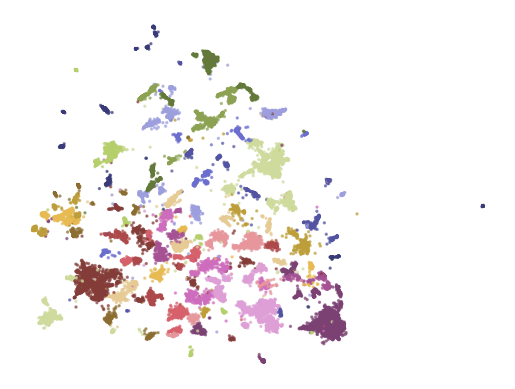

In [31]:
plt.scatter(to_plot.x, to_plot.y, c=to_plot.cluster.astype(int), alpha=0.6, s=2, cmap="tab20b")
plt.axis("off")

### Topic modelling

<img src="./images/genai_74.png" width=1000 />

<img src="./images/genai_75.png" width=1000 />

<img src="./images/genai_76.png" width=1000 />

<img src="./images/genai_77.png" width=1000 />

<img src="./images/genai_78.png" width=1000 />

<img src="./images/genai_79.png" width=1000 />

<img src="./images/genai_80.png" width=1000 />

In [33]:
from bertopic import BERTopic

In [34]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2025-12-14 13:15:28,741 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-14 13:15:47,744 - BERTopic - Dimensionality - Completed ✓
2025-12-14 13:15:47,745 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-14 13:15:48,627 - BERTopic - Cluster - Completed ✓
2025-12-14 13:15:48,634 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-14 13:15:50,174 - BERTopic - Representation - Completed ✓


In [35]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,14064,-1_the_of_and_to,"[the, of, and, to, in, we, language, that, for...",[ Large-scale language models (LMs) pretraine...
1,0,2193,0_question_answer_questions_qa,"[question, answer, questions, qa, answering, a...","[ We propose a novel text generation task, na..."
2,1,2056,1_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, audi...","[ We introduce Wav2Seq, the first self-superv..."
3,2,1539,2_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, healt...",[ Recent years have seen particular interest ...
4,3,947,3_translation_nmt_machine_bleu,"[translation, nmt, machine, bleu, neural, engl...","[ Many language pairs are low resource, meani..."
...,...,...,...,...,...
148,147,52,147_temporal_events_event_relations,"[temporal, events, event, relations, timeml, r...",[ Structured information resulting from tempo...
149,148,52,148_tokenization_subword_tokenizer_byte,"[tokenization, subword, tokenizer, byte, token...",[ Tokenization is a foundational step in Natu...
150,149,51,149_moe_experts_mixture_routing,"[moe, experts, mixture, routing, expert, spars...",[ The Mixture of Experts (MoE) models are an ...
151,150,50,150_prompt_prompts_optimization_prompting,"[prompt, prompts, optimization, prompting, eng...",[ Prompt optimization aims to find the best p...


In [36]:
topic_model.get_topic(0)

[('question', np.float64(0.02147508483612379)),
 ('answer', np.float64(0.01606103064571113)),
 ('questions', np.float64(0.016027373584505632)),
 ('qa', np.float64(0.015684363721343037)),
 ('answering', np.float64(0.01488794635972769)),
 ('answers', np.float64(0.010057005948697373)),
 ('retrieval', np.float64(0.009462957516487082)),
 ('comprehension', np.float64(0.007878219309685333)),
 ('reading', np.float64(0.007332022254727678)),
 ('the', np.float64(0.006312987072905832))]

In [37]:
topic_model.get_representative_docs(0)

['  We propose a novel text generation task, namely Curiosity-driven Question\nGeneration. We start from the observation that the Question Generation task has\ntraditionally been considered as the dual problem of Question Answering, hence\ntackling the problem of generating a question given the text that contains its\nanswer. Such questions can be used to evaluate machine reading comprehension.\nHowever, in real life, and especially in conversational settings, humans tend\nto ask questions with the goal of enriching their knowledge and/or clarifying\naspects of previously gathered information. We refer to these inquisitive\nquestions as Curiosity-driven: these questions are generated with the goal of\nobtaining new information (the answer) which is not present in the input text.\nIn this work, we experiment on this new task using a conversational Question\nAnswering (QA) dataset; further, since the majority of QA dataset are not built\nin a conversational manner, we describe a methodol

In [38]:
topic_model.find_topics("About Large Language models")

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul



([87, -1, 12, 102, 37],
 [np.float32(0.9429821),
  np.float32(0.9236395),
  np.float32(0.9213463),
  np.float32(0.918995),
  np.float32(0.9185262)])

In [39]:
topic_model.get_topic(87)

[('llms', np.float64(0.023220839396410706)),
 ('evaluation', np.float64(0.019195344879937938)),
 ('chinese', np.float64(0.01644700550904354)),
 ('llm', np.float64(0.014669949987834593)),
 ('open', np.float64(0.012538836727484669)),
 ('benchmarks', np.float64(0.011510147207962665)),
 ('large', np.float64(0.010252985948886859)),
 ('benchmark', np.float64(0.010021792202310763)),
 ('capabilities', np.float64(0.009819136890548466)),
 ('models', np.float64(0.009522289897327963))]

In [41]:
from transformers import pipeline

In [42]:
from bertopic.representation import TextGeneration

In [43]:
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords : '[KEYWORDS]'.
Based on the documents and keywords, what is this topic about ?
"""

In [44]:
generator = pipeline("text2text-generation", model="google/flan-t5-small")

Device set to use mps:0


In [45]:
representation_model = TextGeneration(
    generator, prompt=prompt, doc_length=50, tokenizer='whitespace'
)

In [46]:
topic_model.update_topics(abstracts, representation_model=representation_model)

100%|██████████| 153/153 [03:15<00:00,  1.28s/it]


In [47]:
topic_model.topic_representations_

{-1: [('Learning to construct text representations in end-to-end systems can be difficult, as natural languages are highly compositional and task-specific annotated datasets are often limited in size',
   1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 0: [('Question answering', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 1: [('Speech-to-text translation', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 2: [('Science/Tech', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 3: [('Science/Tech', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 4: [('Summarization', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 5: [('Science/Tech', 1),
  ('', 0),
  (

In [51]:
cluster_data = dict()
cluster_data = cluster_data.fromkeys(topic_model.topic_representations_.keys())

In [52]:
for key,value in topic_model.topic_representations_.items():
    topic = topic_model.topic_representations_[key][0][0]
    cluster_data[key] = topic
    print(topic)

Learning to construct text representations in end-to-end systems can be difficult, as natural languages are highly compositional and task-specific annotated datasets are often limited in size
Question answering
Speech-to-text translation
Science/Tech
Science/Tech
Summarization
Science/Tech
gender bias in natural language processing
Relation extraction
Science/Tech
Word embeddings
Syntactic parsing
Legal domain
Human language
Human-machine interaction
Science/Tech
Aspect-based Sentiment Analysis
Sentiment analysis
Science/Tech
Vision-Language Pre-training
Topics
Science/Tech
Multi-label classification
Science/Tech
Adversarial and adversarial attacks
Knowledge graph embedding
Controllable text generation
Emotion recognition in conversation
A coreference resolution system is to cluster all mentions that refer to the same entity in a given context.
Prompt tuning
Science/Tech
Argumentation
Description of the problem of compositionality in distributional semantics
Text simplification
Event E

In [53]:
print(cluster_data)

{-1: 'Learning to construct text representations in end-to-end systems can be difficult, as natural languages are highly compositional and task-specific annotated datasets are often limited in size', 0: 'Question answering', 1: 'Speech-to-text translation', 2: 'Science/Tech', 3: 'Science/Tech', 4: 'Summarization', 5: 'Science/Tech', 6: 'gender bias in natural language processing', 7: 'Relation extraction', 8: 'Science/Tech', 9: 'Word embeddings', 10: 'Syntactic parsing', 11: 'Legal domain', 12: 'Human language', 13: 'Human-machine interaction', 14: 'Science/Tech', 15: 'Aspect-based Sentiment Analysis', 16: 'Sentiment analysis', 17: 'Science/Tech', 18: 'Vision-Language Pre-training', 19: 'Topics', 20: 'Science/Tech', 21: 'Multi-label classification', 22: 'Science/Tech', 23: 'Adversarial and adversarial attacks', 24: 'Knowledge graph embedding', 25: 'Controllable text generation', 26: 'Emotion recognition in conversation', 27: 'A coreference resolution system is to cluster all mentions t

In [62]:
# Show all rows/columns + allow long cell text
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [63]:
df = pd.DataFrame(list(cluster_data.items()), columns=["Key", "Value"])


In [64]:
df

,Key,Value
0,-1,"Learning to construct text representations in end-to-end systems can be difficult, as natural languages are highly compositional and task-specific annotated datasets are often limited in size"
1,0,Question answering
2,1,Speech-to-text translation
3,2,Science/Tech
4,3,Science/Tech
5,4,Summarization
6,5,Science/Tech
7,6,gender bias in natural language processing
8,7,Relation extraction
9,8,Science/Tech
